In [34]:

# Step 0: Data Cleaning & Preprocessing

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score
)
from sklearn.model_selection import cross_val_score, StratifiedKFold


# Load the dataset
data = pd.read_csv("train.csv")  
print("Shape of dataset:", data.shape)
print("\nFirst 5 rows:\n", data.head())

#  Drop unwanted columns (like ID)
if 'ID' in data.columns:
    data.drop('ID', axis=1, inplace=True)

#  Check for missing/null values
print("\nMissing values before handling:\n", data.isnull().sum())

# Handle missing values
for col in data.columns:
    if data[col].isnull().sum() > 0:
        if data[col].dtype == 'object':
            data[col].fillna(data[col].mode()[0], inplace=True)   # mode for categorical
        else:
            data[col].fillna(data[col].mean(), inplace=True)      # mean for numeric

print("\nMissing values after handling:\n", data.isnull().sum())


#  Step 1: Encode Categorical Features


categorical_cols = ['Warehouse_block', 'Mode_of_Shipment', 
                    'Product_importance', 'Gender']

# Using Label Encoding
le = LabelEncoder()
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

print("\nCategorical columns encoded successfully!")


# Step 2: Normalize Numerical Features

numerical_cols = ['Customer_care_calls', 'Customer_rating', 
                  'Cost_of_the_Product', 'Prior_purchases', 
                  'Discount_offered', 'Weight_in_gms']


print("\nNumerical columns normalized successfully!")


# Final Check


print("\nFinal dataset info:")
print(data.info())

print("\nSample after preprocessing:\n", data.head())


Shape of dataset: (10999, 12)

First 5 rows:
    ID Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0   1               D           Flight                    4                2   
1   2               F           Flight                    4                5   
2   3               A           Flight                    2                2   
3   4               B           Flight                    3                3   
4   5               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183                4                low      M   
3                  176                4             medium      M   
4                  184                3             medium      F   

   Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  


In [35]:

#  Shipping Dataset - Univariate & Bivariate Analysis


# For better plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)
print("Shape of dataset:", data.shape)
print("\nFirst 5 rows:\n", data.head())





Shape of dataset: (10999, 11)

First 5 rows:
    Warehouse_block  Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0                3                 0                    4                2   
1                4                 0                    4                5   
2                0                 0                    2                2   
3                1                 0                    3                3   
4                2                 0                    2                2   

   Cost_of_the_Product  Prior_purchases  Product_importance  Gender  \
0                  177                3                   1       0   
1                  216                2                   1       1   
2                  183                4                   1       1   
3                  176                4                   2       1   
4                  184                3                   2       0   

   Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  



Value counts for Warehouse_block:
Warehouse_block
4    3666
3    1834
0    1833
1    1833
2    1833
Name: count, dtype: int64


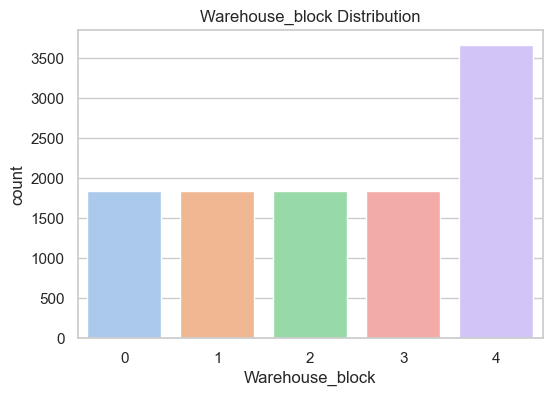


Value counts for Mode_of_Shipment:
Mode_of_Shipment
2    7462
0    1777
1    1760
Name: count, dtype: int64


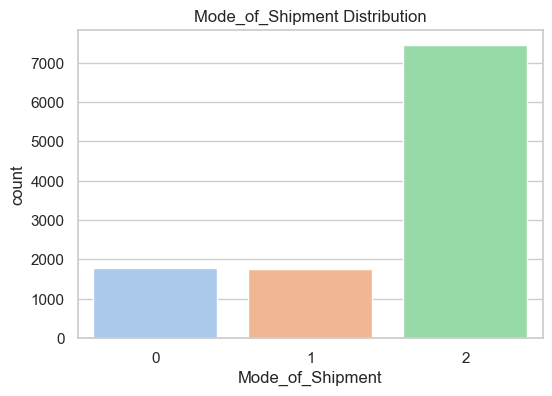


Value counts for Product_importance:
Product_importance
1    5297
2    4754
0     948
Name: count, dtype: int64


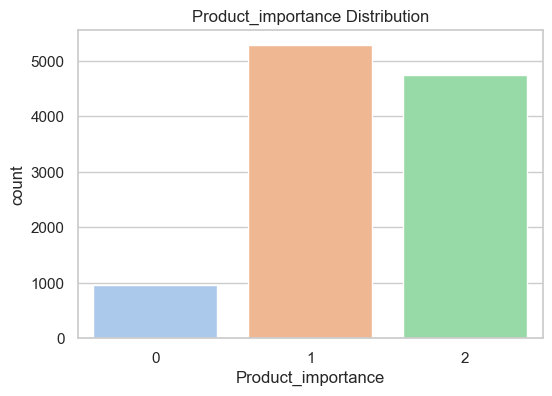


Value counts for Gender:
Gender
0    5545
1    5454
Name: count, dtype: int64


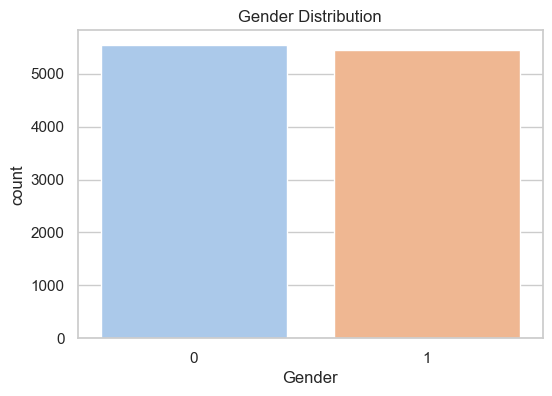


Value counts for Reached.on.Time_Y.N:
Reached.on.Time_Y.N
1    6563
0    4436
Name: count, dtype: int64


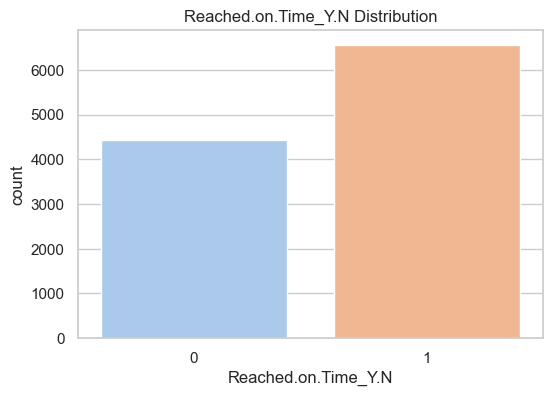

In [36]:

# 3. Univariate Analysis (Categorical Variables)


categorical_cols = ['Warehouse_block', 'Mode_of_Shipment', 
                    'Product_importance', 'Gender', 
                    'Reached.on.Time_Y.N']

for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(data[col].value_counts())
    
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=data,hue=col,  palette="pastel", legend=False)  
    plt.title(f"{col} Distribution")
    plt.show()


In [37]:
# --- Numerical Variables ---
numerical_cols = ['Customer_care_calls', 'Customer_rating', 
                  'Cost_of_the_Product', 'Prior_purchases', 
                  'Discount_offered', 'Weight_in_gms']

for col in numerical_cols:
    print(f"\nSummary stats for {col}:")
    print(data[col].describe())


Summary stats for Customer_care_calls:
count    10999.000000
mean         4.054459
std          1.141490
min          2.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: Customer_care_calls, dtype: float64

Summary stats for Customer_rating:
count    10999.000000
mean         2.990545
std          1.413603
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: Customer_rating, dtype: float64

Summary stats for Cost_of_the_Product:
count    10999.000000
mean       210.196836
std         48.063272
min         96.000000
25%        169.000000
50%        214.000000
75%        251.000000
max        310.000000
Name: Cost_of_the_Product, dtype: float64

Summary stats for Prior_purchases:
count    10999.000000
mean         3.567597
std          1.522860
min          2.000000
25%          3.000000
50%          3.000000
75%          4.000000
max         10.000000
Name: Prior_purchases,

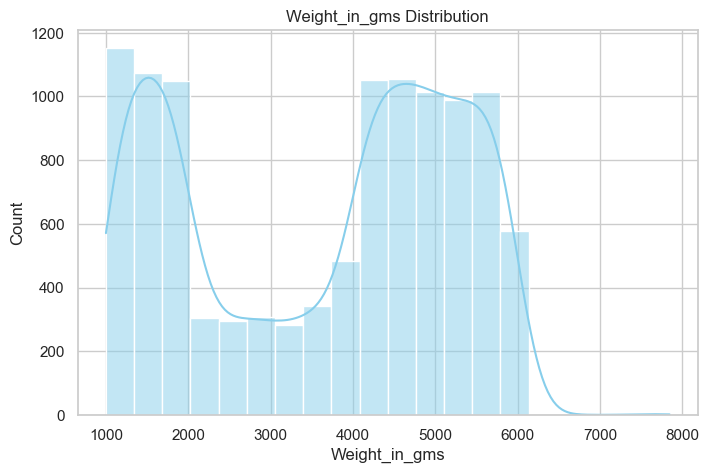

In [38]:
# Histogram
sns.histplot(data[col], kde=True, bins=20, color="skyblue")
plt.title(f"{col} Distribution")
plt.show()


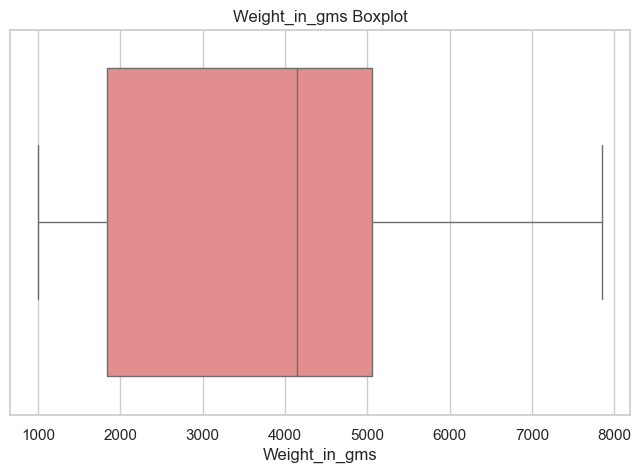

In [39]:
# Boxplot
sns.boxplot(x=data[col], color="lightcoral")
plt.title(f"{col} Boxplot")
plt.show()


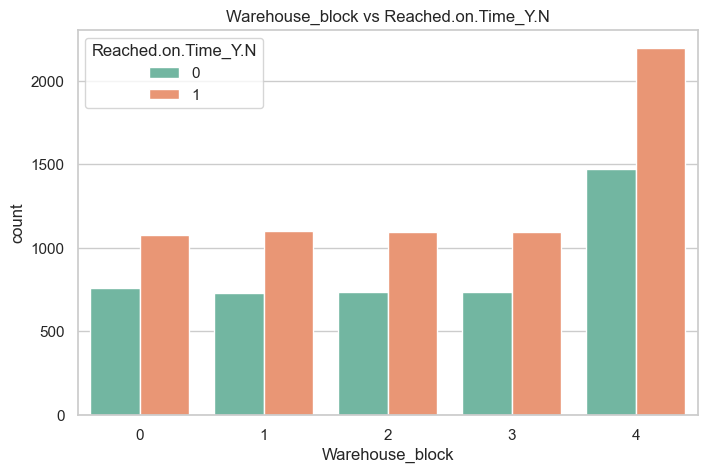

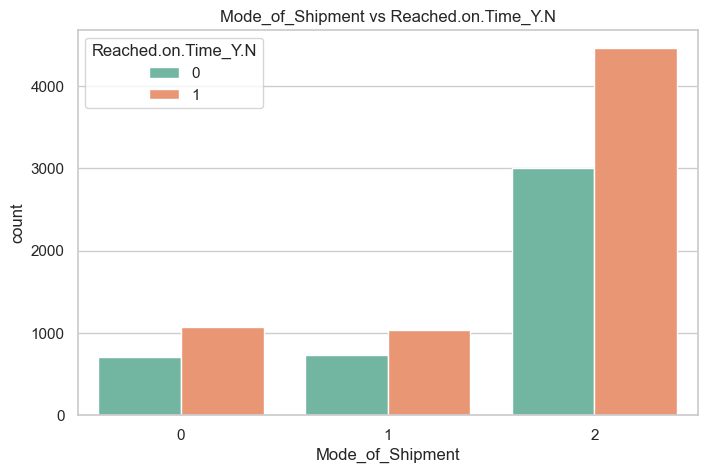

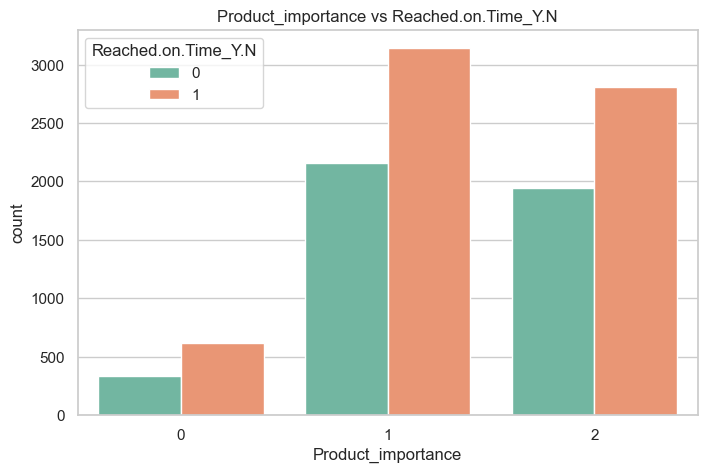

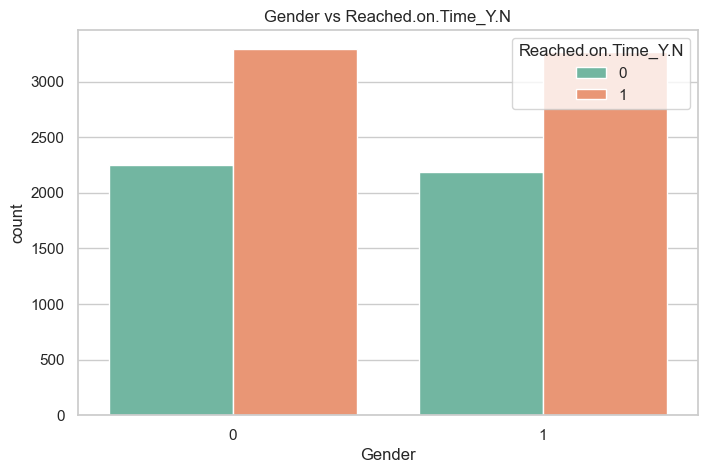

In [40]:

# 4. Bivariate Analysis


target_col = 'Reached.on.Time_Y.N'   

# --- Categorical vs Target ---
for col in ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']:
    sns.countplot(x=col, hue=target_col, data=data, palette="Set2")
    plt.title(f"{col} vs {target_col}")
    plt.show()





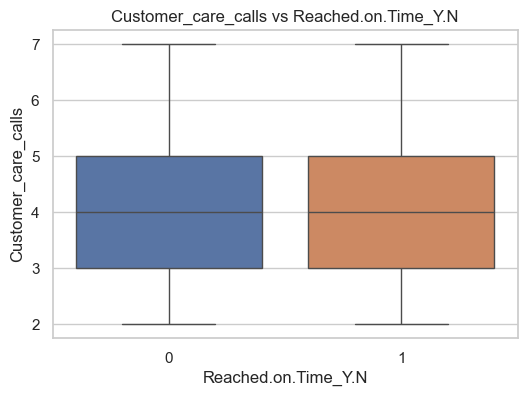

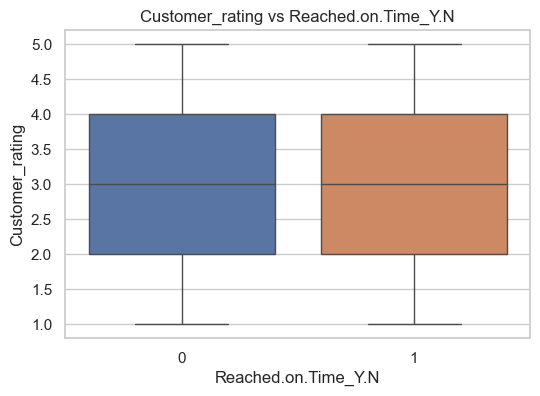

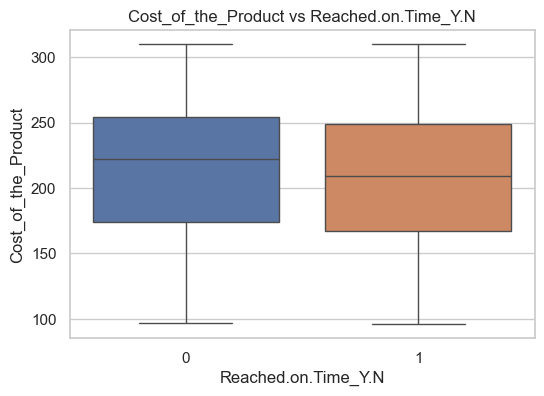

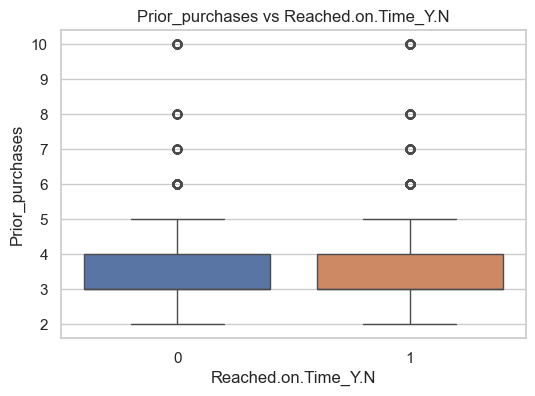

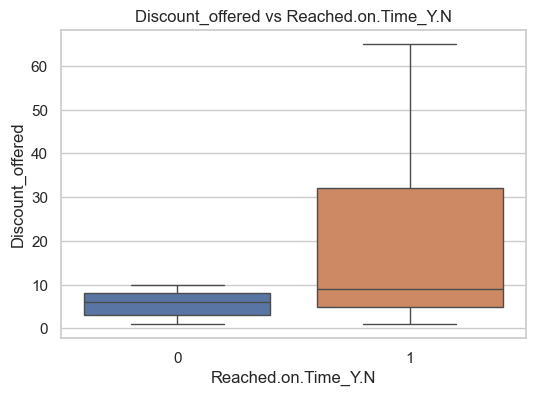

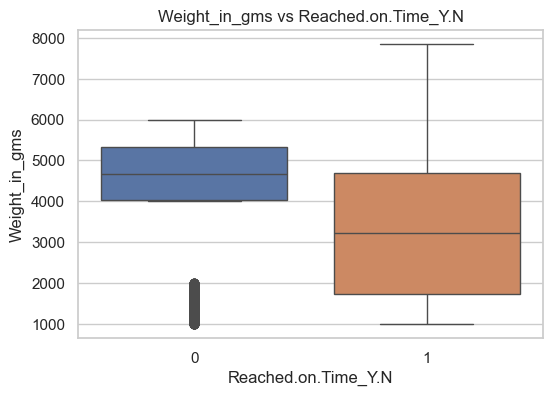

In [41]:
# --- Numerical vs Target (clean, no warnings) ---
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=target_col, y=col, data=data, hue=target_col, legend=False)  # palette optional
    plt.title(f"{col} vs {target_col}")
    plt.show()


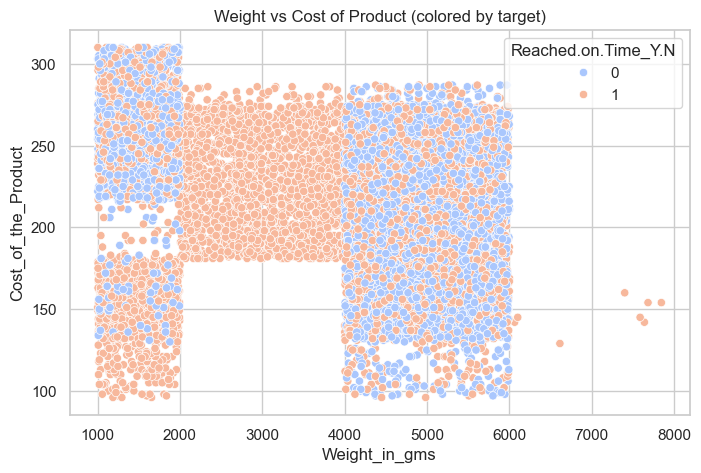

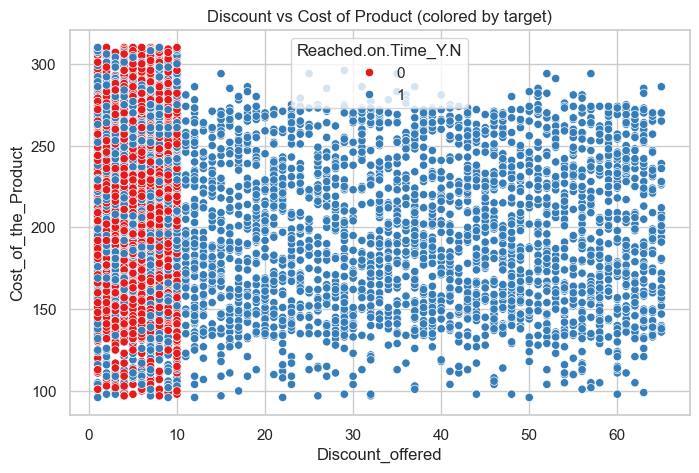

In [42]:
# --- Numerical vs Numerical ---
sns.scatterplot(x='Weight_in_gms', y='Cost_of_the_Product', 
                hue=target_col, data=data, palette="coolwarm")
plt.title("Weight vs Cost of Product (colored by target)")
plt.show()

sns.scatterplot(x='Discount_offered', y='Cost_of_the_Product', 
                hue=target_col, data=data, palette="Set1")
plt.title("Discount vs Cost of Product (colored by target)")
plt.show()


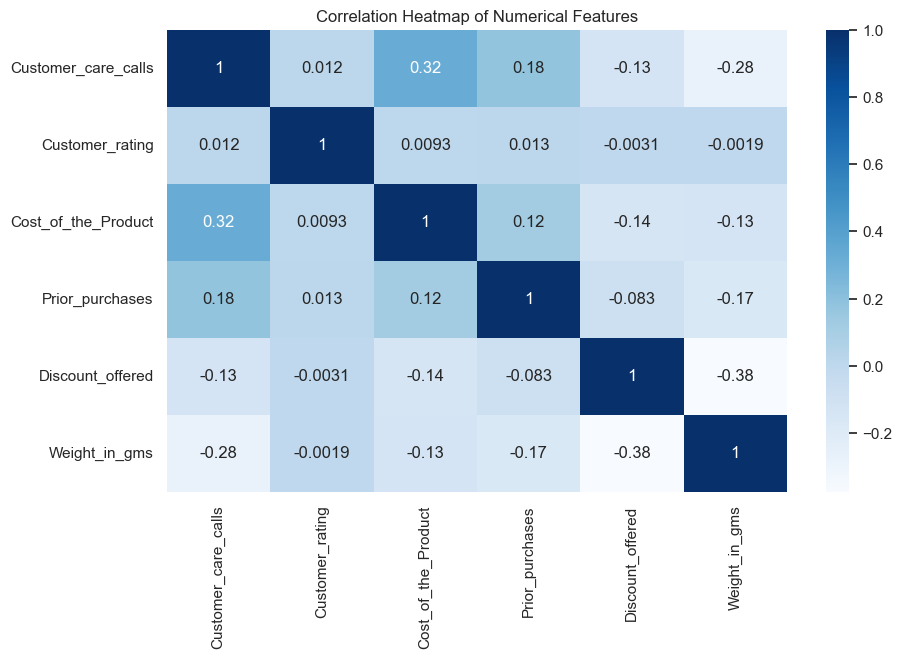

In [43]:
# --- Correlation Heatmap ---
plt.figure(figsize=(10,6))
sns.heatmap(data[numerical_cols].corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

Value counts:
Reached.on.Time_Y.N
1    6563
0    4436
Name: count, dtype: int64


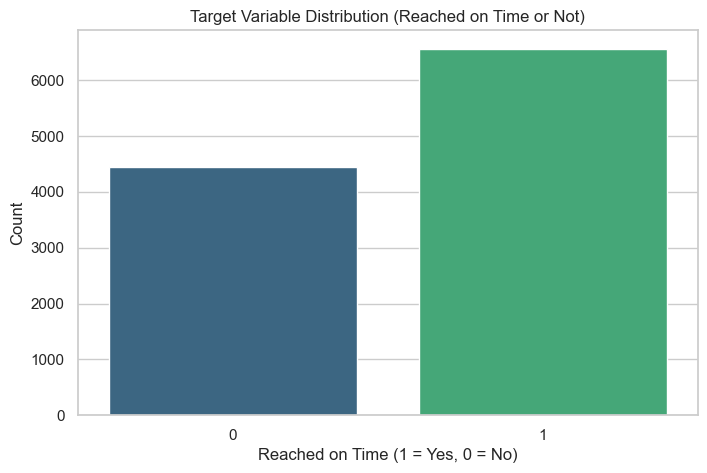


Percentage distribution:
Reached.on.Time_Y.N
1    59.669061
0    40.330939
Name: proportion, dtype: float64


In [44]:
 #Target Variable Analysis




target_col = 'Reached.on.Time_Y.N'

# 1️⃣ Count values
print("Value counts:")
print(data[target_col].value_counts())

# 2️⃣ Plot distribution (Warning-Free)
sns.countplot(x=target_col, hue=target_col, data=data, palette="viridis", legend=False)
plt.title("Target Variable Distribution (Reached on Time or Not)")
plt.xlabel("Reached on Time (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

# 3️⃣ Percentage distribution
counts = data[target_col].value_counts(normalize=True) * 100
print("\nPercentage distribution:")
print(counts)


In [45]:
# Copy dataset
from sklearn.preprocessing import StandardScaler

encode_data = data.copy()

# Initialize LabelEncoder
le = LabelEncoder()

# Label Encode
encode_data['Product_importance'] = le.fit_transform(encode_data['Product_importance'])
encode_data['Gender'] = le.fit_transform(encode_data['Gender'])

# One-Hot Encode nominal categorical columns
encode_data = pd.get_dummies(encode_data,
                             columns=['Warehouse_block', 'Mode_of_Shipment'],
                             drop_first=True)

# Check
encode_data.head()
# Check only the encoded columns
encode_data[['Product_importance', 'Gender'] +
            [col for col in encode_data.columns if 'Warehouse_block' in col or 'Mode_of_Shipment' in col]].head()
# Convert all boolean columns to 0/1
encode_data = encode_data.astype(int)
encode_data.head()
# Initialize StandardScaler
std_scaler = StandardScaler()
# Columns to normalize
num_cols = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
            'Prior_purchases', 'Discount_offered', 'Weight_in_gms']

# Apply to numerical columns
std_scaled_data = encode_data.copy()
std_scaled_data[num_cols] = std_scaler.fit_transform(encode_data[num_cols])

# Check results
print(std_scaled_data[num_cols].describe())

       Customer_care_calls  Customer_rating  Cost_of_the_Product  \
count         1.099900e+04     1.099900e+04         1.099900e+04   
mean          2.325624e-16    -5.975562e-17        -1.343694e-16   
std           1.000045e+00     1.000045e+00         1.000045e+00   
min          -1.799887e+00    -1.408199e+00        -2.376077e+00   
25%          -9.237994e-01    -7.007551e-01        -8.571765e-01   
50%          -4.771132e-02     6.689172e-03         7.913188e-02   
75%           8.283768e-01     7.141334e-01         8.489855e-01   
max           2.580553e+00     1.421578e+00         2.076590e+00   

       Prior_purchases  Discount_offered  Weight_in_gms  
count     1.099900e+04      1.099900e+04   1.099900e+04  
mean     -2.067221e-17     -4.134443e-17  -1.188652e-16  
std       1.000045e+00      1.000045e+00   1.000045e+00  
min      -1.029424e+00     -7.635530e-01  -1.610109e+00  
25%      -3.727348e-01     -5.784225e-01  -1.097360e+00  
50%      -3.727348e-01     -3.932921e-0

Any NaN values left? 0

Cost_to_Weight_ratio summary:
 count    10999.000000
mean         0.079229
std          0.055913
min          0.016482
25%          0.039771
50%          0.054916
75%          0.103455
max          0.309073
Name: Cost_to_Weight_ratio, dtype: float64


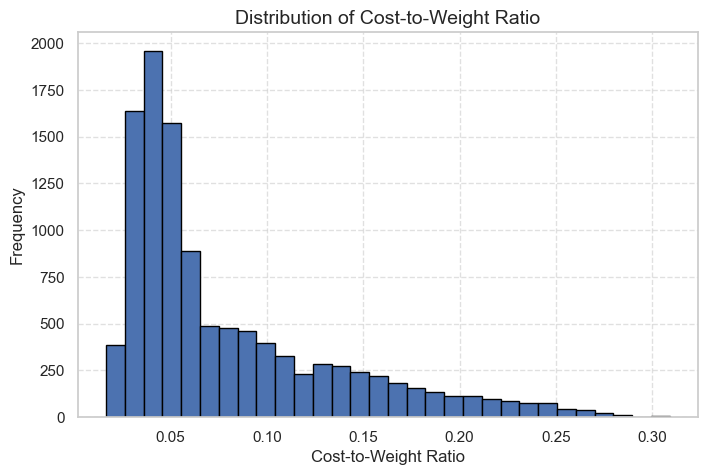

In [46]:
encode_data['Cost_to_Weight_ratio'] = encode_data['Cost_of_the_Product'] / encode_data['Weight_in_gms']

#Handling infinity and NaN values
encode_data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN values  with the median of valid ratios
encode_data['Cost_to_Weight_ratio'].fillna(encode_data['Cost_to_Weight_ratio'].median(), inplace=True)
print("Any NaN values left?", encode_data.isnull().sum().sum())
print("\nCost_to_Weight_ratio summary:\n", encode_data['Cost_to_Weight_ratio'].describe())

# Preview final dataset
encode_data.head()
plt.figure(figsize=(8,5))
plt.hist(encode_data['Cost_to_Weight_ratio'], bins=30, edgecolor='black')
plt.title('Distribution of Cost-to-Weight Ratio', fontsize=14)
plt.xlabel('Cost-to-Weight Ratio')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [47]:
# For target column
print("Target Variable (Reached.on.Time_Y.N):")
print(data['Reached.on.Time_Y.N'].value_counts())
print("\nNormalized Value Counts (Proportion):")
print(data['Reached.on.Time_Y.N'].value_counts(normalize=True))
# For all categorical columns
categorical_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(data[col].value_counts())
    print("\nNormalized:")
    print(data[col].value_counts(normalize=True))
   

Target Variable (Reached.on.Time_Y.N):
Reached.on.Time_Y.N
1    6563
0    4436
Name: count, dtype: int64

Normalized Value Counts (Proportion):
Reached.on.Time_Y.N
1    0.596691
0    0.403309
Name: proportion, dtype: float64

Column: Warehouse_block
Warehouse_block
4    3666
3    1834
0    1833
1    1833
2    1833
Name: count, dtype: int64

Normalized:
Warehouse_block
4    0.333303
3    0.166742
0    0.166652
1    0.166652
2    0.166652
Name: proportion, dtype: float64

Column: Mode_of_Shipment
Mode_of_Shipment
2    7462
0    1777
1    1760
Name: count, dtype: int64

Normalized:
Mode_of_Shipment
2    0.678425
0    0.161560
1    0.160015
Name: proportion, dtype: float64

Column: Product_importance
Product_importance
1    5297
2    4754
0     948
Name: count, dtype: int64

Normalized:
Product_importance
1    0.481589
2    0.432221
0    0.086190
Name: proportion, dtype: float64

Column: Gender
Gender
0    5545
1    5454
Name: count, dtype: int64

Normalized:
Gender
0    0.504137
1    0.49

In [48]:
encode_data.select_dtypes(include=['object']).columns
encode_data.dtypes
X = encode_data.drop('Reached.on.Time_Y.N', axis=1)
y = encode_data['Reached.on.Time_Y.N']


In [49]:
X


,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Warehouse_block_1,Warehouse_block_2,Warehouse_block_3,Warehouse_block_4,Mode_of_Shipment_1,Mode_of_Shipment_2,Cost_to_Weight_ratio
0,4,2,177,3,1,0,44,1233,0,0,1,0,0,0,0.143552
1,4,5,216,2,1,1,59,3088,0,0,0,1,0,0,0.069948
2,2,2,183,4,1,1,48,3374,0,0,0,0,0,0,0.054238
3,3,3,176,4,2,1,10,1177,1,0,0,0,0,0,0.149533
4,2,2,184,3,2,0,46,2484,0,1,0,0,0,0,0.074074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,4,1,252,5,2,0,1,1538,0,0,0,0,0,1,0.163849
10995,4,1,232,5,2,0,6,1247,1,0,0,0,0,1,0.186047
10996,5,4,242,5,1,0,4,1155,0,1,0,0,0,1,0.209524
10997,5,2,223,6,2,1,2,1210,0,0,0,1,0,1,0.184298


In [50]:
y

0        1
1        1
2        1
3        1
4        1
        ..
10994    1
10995    0
10996    0
10997    0
10998    0
Name: Reached.on.Time_Y.N, Length: 10999, dtype: int64

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Further split training data into train + validation
X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [52]:
# shape of the Training, testing dataset after splitting
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (8799, 15)
Testing set shape: (2200, 15)


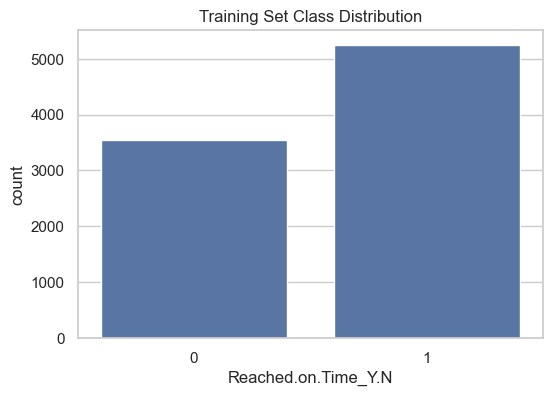

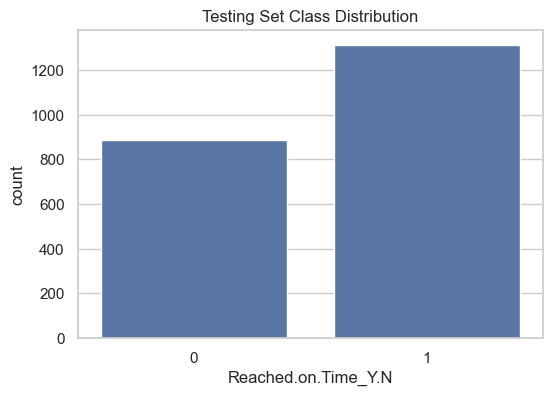

In [53]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Training Set Class Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x=y_test)
plt.title("Testing Set Class Distribution")
plt.show()

In [54]:
from imblearn.over_sampling import SMOTE
from collections import Counter   # ✅ FIX

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply to training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check new class distribution
print("After SMOTE class distribution:", Counter(y_train_resampled))


After SMOTE class distribution: Counter({0: 5250, 1: 5250})


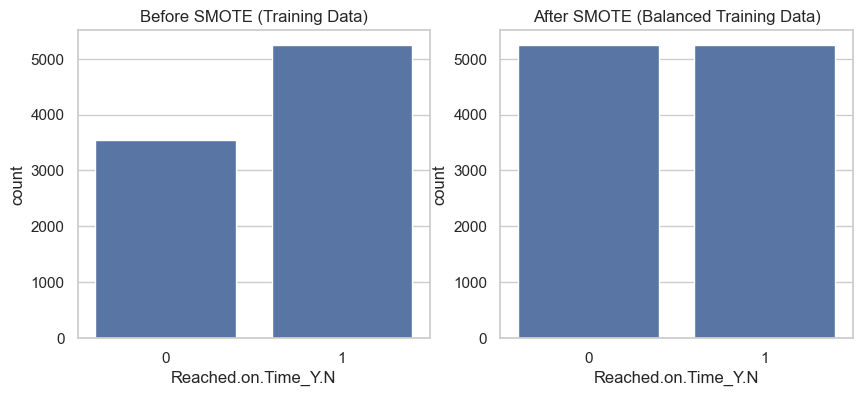

In [55]:
# Visualization before & after
fig, ax = plt.subplots(1, 2, figsize=(10,4))
sns.countplot(x=y_train, ax=ax[0])
ax[0].set_title("Before SMOTE (Training Data)")
sns.countplot(x=y_train_resampled, ax=ax[1])
ax[1].set_title("After SMOTE (Balanced Training Data)")
plt.show()

In [56]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier           # ✅ REQUIRED
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB                # ✅ REQUIRED
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from lightgbm import LGBMClassifier                       # ✅ REQUIRED (if using LightGBM)
from catboost import CatBoostClassifier                   # ✅ REQUIRED (if using CatBoost)




cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
models = {
    "Logistic Regression": LogisticRegression(C=0.5, max_iter=1000, random_state=42),  # L2 regularization (smaller C = stronger)
    
    "Decision Tree": DecisionTreeClassifier(max_depth=8, min_samples_split=10, min_samples_leaf=5, random_state=42),
    
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=42, n_jobs=-1),
    
    "Naive Bayes": GaussianNB(),
    
    "KNN": KNeighborsClassifier(n_neighbors=9),  # more neighbors → smoother, less overfitting
    
    "SVM": SVC(C=0.5, kernel='rbf', gamma='scale', random_state=42),
    
    "XGBoost": XGBClassifier(
        learning_rate=0.05, n_estimators=500, max_depth=6,subsample=0.8, colsample_bytree=0.8, reg_lambda=0.5, use_label_encoder=False, eval_metric='logloss', random_state=42),
    
    "LightGBM": LGBMClassifier(
        learning_rate=0.05, n_estimators=500, max_depth=6,num_leaves=20, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.2, reg_lambda=0.5, random_state=42),
    
    "CatBoost": CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6, l2_leaf_reg=5, verbose=False, random_state=42)
}

In [57]:
from sklearn.pipeline import Pipeline


results = []

for name, model in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    
    # Cross-validation accuracy (10-fold)
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    
    results.append({
        'Model': name,
        'Mean CV Accuracy': round(np.mean(cv_scores), 4),
        'Std Dev': round(np.std(cv_scores), 4)
    })

results_df = pd.DataFrame(results).sort_values(by='Mean CV Accuracy', ascending=False)
print("\n Cross-validation results (Overfitting check):")
print(results_df)


 Cross-validation results (Overfitting check):
                 Model  Mean CV Accuracy  Std Dev
2        Random Forest            0.6769   0.0100
1        Decision Tree            0.6726   0.0173
7             LightGBM            0.6610   0.0159
8             CatBoost            0.6588   0.0170
5                  SVM            0.6583   0.0117
3          Naive Bayes            0.6550   0.0055
6              XGBoost            0.6527   0.0171
0  Logistic Regression            0.6498   0.0087
4                  KNN            0.6329   0.0181


In [58]:
# ==============================
# ✅ IMPORTS
# ==============================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier  # 👈 Removed set_config
from catboost import CatBoostClassifier

# ==============================
# ✅ FIXED RANDOM SEED
# ==============================
RND = 42
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RND)

# ==============================
# ✅ MODELS
# ==============================
models = {
    "Logistic Regression": LogisticRegression(
        C=0.1, penalty='l2', solver='liblinear', random_state=RND
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, min_samples_split=10, min_samples_leaf=4, random_state=RND
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_split=5,
        min_samples_leaf=3, max_features='sqrt', random_state=RND
    ),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(
        C=0.5, kernel='rbf', gamma='scale', probability=True, random_state=RND
    ),
    "XGBoost": XGBClassifier(
        max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1, n_estimators=200, random_state=RND, eval_metric='logloss',
        verbosity=0
    ),
    "LightGBM": LGBMClassifier(
        num_leaves=20, max_depth=6, subsample=0.8, reg_lambda=0.5,
        learning_rate=0.05, n_estimators=200, random_state=RND,
        verbose=-1     # ✅ This line suppresses warnings
    ),
    "CatBoost": CatBoostClassifier(
        depth=6, learning_rate=0.05, l2_leaf_reg=3,
        n_estimators=200, verbose=0, random_state=RND
    )
}

# ==============================
# ✅ CROSS-VALIDATION
# ==============================
cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    cv_results.append({
        "Model": name,
        "Mean CV Accuracy": round(np.mean(scores), 4),
        "Std Dev": round(np.std(scores), 4)
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="Mean CV Accuracy", ascending=False)
print(cv_results_df)


                 Model  Mean CV Accuracy  Std Dev
1        Decision Tree            0.6825   0.0150
2        Random Forest            0.6753   0.0093
6              XGBoost            0.6743   0.0114
8             CatBoost            0.6664   0.0153
7             LightGBM            0.6650   0.0148
3                  KNN            0.6578   0.0156
5                  SVM            0.6568   0.0112
4          Naive Bayes            0.6543   0.0049
0  Logistic Regression            0.6404   0.0129


In [59]:
# Display results
cv_df = pd.DataFrame(cv_results).sort_values(by="Mean CV Accuracy", ascending=False)
print("\nCross-validation results (After Regularization to Fix Overfitting):")
print(cv_df.to_string(index=False))


Cross-validation results (After Regularization to Fix Overfitting):
              Model  Mean CV Accuracy  Std Dev
      Decision Tree            0.6825   0.0150
      Random Forest            0.6753   0.0093
            XGBoost            0.6743   0.0114
           CatBoost            0.6664   0.0153
           LightGBM            0.6650   0.0148
                KNN            0.6578   0.0156
                SVM            0.6568   0.0112
        Naive Bayes            0.6543   0.0049
Logistic Regression            0.6404   0.0129


In [60]:
models = {
    "Logistic Regression": LogisticRegression(C=0.5, max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, min_samples_split=10, min_samples_leaf=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=42, n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=9),
    "SVM": SVC(C=0.5, kernel='rbf', gamma='scale', probability=True, random_state=42),
    "XGBoost": XGBClassifier(
        learning_rate=0.05, n_estimators=500, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=0.5,
        use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(
        learning_rate=0.05, n_estimators=500, max_depth=6, num_leaves=20,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.2, reg_lambda=0.5, random_state=42),
    "CatBoost": CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6, l2_leaf_reg=5, verbose=False, random_state=42)
}


🔹 Training and evaluating Logistic Regression...

📌 Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.54      0.59      0.57       710
           1       0.71      0.66      0.68      1050

    accuracy                           0.63      1760
   macro avg       0.63      0.63      0.63      1760
weighted avg       0.64      0.63      0.64      1760


🔹 Training and evaluating Decision Tree...

📌 Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.58      0.93      0.72       710
           1       0.92      0.54      0.68      1050

    accuracy                           0.70      1760
   macro avg       0.75      0.74      0.70      1760
weighted avg       0.78      0.70      0.70      1760


🔹 Training and evaluating Random Forest...

📌 Classification Report for Random Forest:
              precision    recall  f1-score   support

           0   

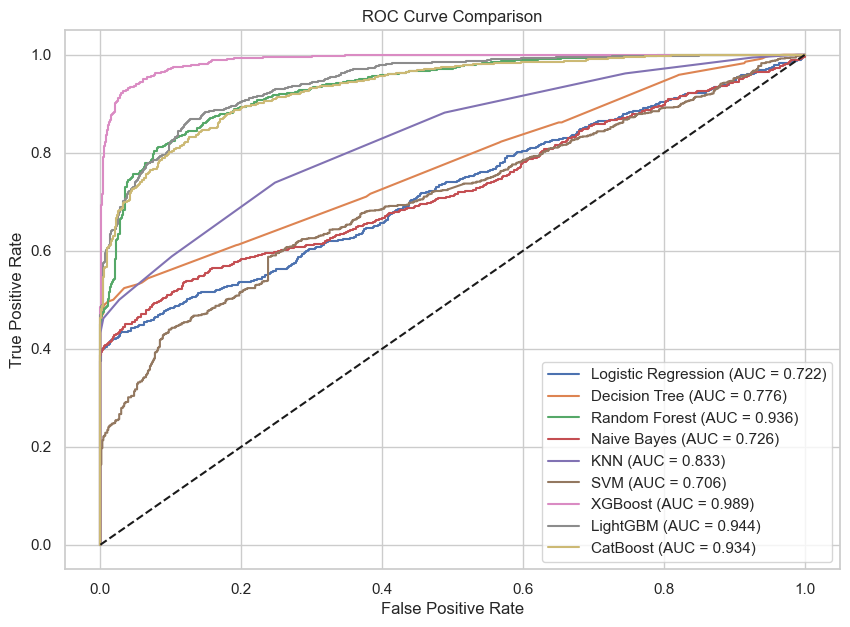

In [61]:
# ==== REQUIRED IMPORTS ====
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report
)
import matplotlib.pyplot as plt

results = {}
comparison = []

plt.figure(figsize=(10, 7))
for name, model in models.items():
    print(f"\n🔹 Training and evaluating {name}...")
    
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_val, y_val_pred)
    prec = precision_score(y_val, y_val_pred)
    rec = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    roc_auc = roc_auc_score(y_val, y_val_prob)
    
    print(f"\n📌 Classification Report for {name}:")
    print(classification_report(y_val, y_val_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_val, y_val_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")
    
    comparison.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1 Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4)
    })

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


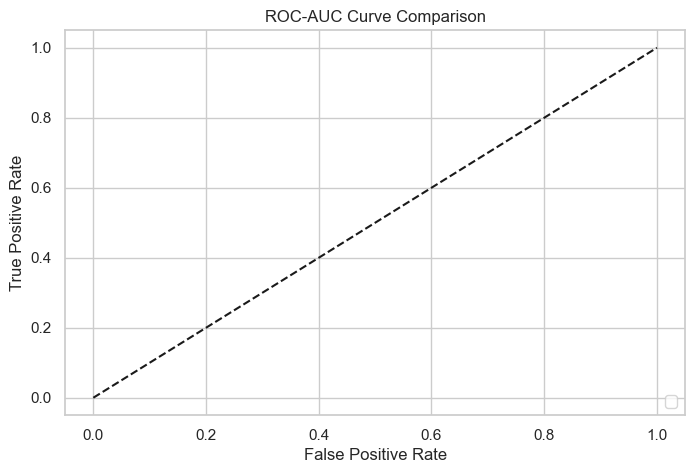

In [62]:
# --- Plot ROC Curve ---
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC-AUC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [63]:
# --- Final Comparison Table ---
comparison_df = pd.DataFrame(comparison).sort_values(by='ROC-AUC', ascending=False)
print("\nFinal Model Comparison Table:")
print(comparison_df)


Final Model Comparison Table:
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
6              XGBoost    0.9375     0.9816  0.9124    0.9457   0.9892
7             LightGBM    0.8409     0.9355  0.7876    0.8552   0.9440
2        Random Forest    0.7739     0.9711  0.6400    0.7715   0.9360
8             CatBoost    0.8278     0.9431  0.7571    0.8399   0.9335
4                  KNN    0.7443     0.8151  0.7390    0.7752   0.8329
1        Decision Tree    0.7006     0.9225  0.5438    0.6842   0.7758
3          Naive Bayes    0.6472     0.9714  0.4210    0.5874   0.7263
0  Logistic Regression    0.6347     0.7070  0.6619    0.6837   0.7223
5                  SVM    0.6517     0.7187  0.6838    0.7008   0.7062


In [64]:
print(X.columns.tolist())


['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms', 'Warehouse_block_1', 'Warehouse_block_2', 'Warehouse_block_3', 'Warehouse_block_4', 'Mode_of_Shipment_1', 'Mode_of_Shipment_2', 'Cost_to_Weight_ratio']


In [65]:
import joblib
from xgboost import XGBClassifier

# Retrain on full dataset
final_model = XGBClassifier(random_state=42)
final_model.fit(X_train, y_train)

# Save the model
joblib.dump(final_model, "xgboost_shipment_model.pkl")
print("Model saved successfully!")


Model saved successfully!


In [66]:
from sklearn.metrics import precision_recall_curve, roc_curve

y_proba = model.predict_proba(X_test)[:, 1]  # Probability of class 1

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Find threshold that gives best balance between sensitivity and specificity
import numpy as np
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print("Optimal threshold:", optimal_threshold)


Optimal threshold: 0.711199508182273
